In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt


In [2]:
# Leer el dataset desde CSV
df_csv = pd.read_csv("data/mini_comisariato.csv", encoding="utf-8-sig")

print("Dataset CSV cargado:", df_csv.shape)
print(df_csv.head())


Dataset CSV cargado: (5000, 6)
  Producto  Precio  Cantidad       Fecha                      Cliente  \
0   Azúcar    7.12         4  2025-09-12     Flor Lidia Caro Morcillo   
1    Carne    4.97         3  2025-12-22                  Vera Tirado   
2    Queso    9.44         6  2026-04-10           Nuria Macías-Muñoz   
3    Queso   14.29         1  2026-01-11  Albano Adolfo Saavedra Polo   
4    Arroz    9.17         4  2026-05-09     Carolina Cifuentes Jordá   

       Ciudad  
0      Burgos  
1     Granada  
2      Madrid  
3  Valladolid  
4      Málaga  


In [4]:
# Conexión a la base de datos
conn = sqlite3.connect("data/comisariato.db")

# Leer tabla completa con Pandas
df_sql = pd.read_sql("SELECT * FROM ventas_plasticos", conn)

conn.close()

print("Dataset SQL cargado:", df_sql.shape)
print(df_sql.head())


Dataset SQL cargado: (5000, 6)
                       Producto  Precio  Cantidad       Fecha  \
0                        Tupper   21.50        16  2026-04-11   
1  Utensilio de cocina plástico   43.05         7  2025-06-19   
2              Cubo organizador   44.12        14  2025-12-10   
3       Cubo de basura plástico   17.43         4  2025-08-29   
4                Silla plástica   30.20         5  2026-05-18   

                    Cliente      Ciudad  
0  Calixto Posada Velázquez      Murcia  
1        Tomás Amo Armengol      Toledo  
2    Fernanda Pizarro Rueda  Valladolid  
3    Duilio Hernandez-Bosch    Baleares  
4       Mireia Solé Hidalgo      Burgos  


El producto con más ventas fue  Queso con la cantidad en $ 5548.94


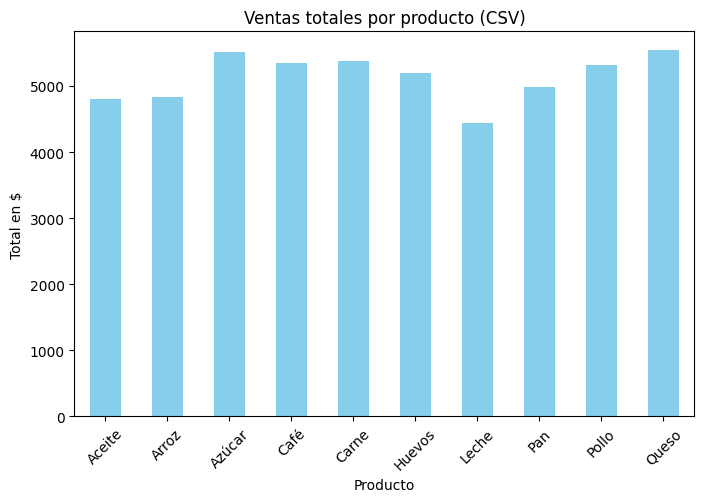

In [13]:
#Ventas totales por producto (CSV)
ventas_por_producto = df_csv.groupby("Producto")["Precio"].sum()

# Identificar el productos de mayor ventas
producto_top = ventas_por_producto.idxmax()
precio_top = ventas_por_producto.max()

print("El producto con más ventas fue ", producto_top, "con la cantidad en $", precio_top)

plt.figure(figsize=(8,5))
ventas_por_producto.plot(kind="bar", color="skyblue")
plt.title("Ventas totales por producto (CSV)")
plt.xlabel("Producto")
plt.ylabel("Total en $")
plt.xticks(rotation=45)
plt.show()


El mes con más ventas fue  2025-08 con 11669.94 unidades.


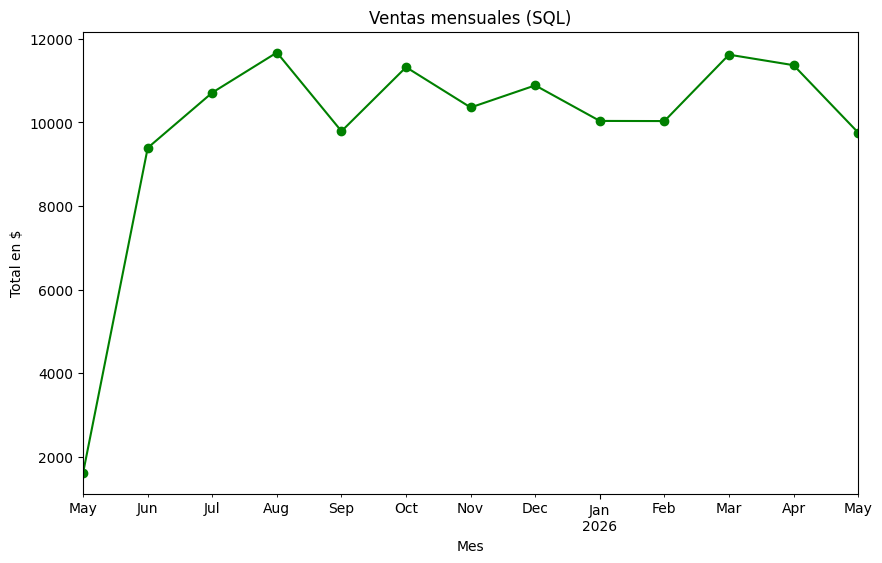

In [6]:
#Evolución mensual de ventas (desde SQL)
# Convertir columna Fecha a tipo datetime
df_sql["Fecha"] = pd.to_datetime(df_sql["Fecha"])

# Agrupar por mes
ventas_mensuales = df_sql.groupby(df_sql["Fecha"].dt.to_period("M"))["Precio"].sum()

# Identificar el mes con mayor ventas
mes_top = ventas_mensuales.idxmax()
ventas_top = ventas_mensuales.max()

print("El mes con más ventas fue ", mes_top, "con", ventas_top, "unidades.")


plt.figure(figsize=(10,6))
ventas_mensuales.plot(kind="line", marker="o", color="green")
plt.title("Ventas mensuales (SQL)")
plt.xlabel("Mes")
plt.ylabel("Total en $")
plt.show()


In [14]:
# Combinar ambos datasets
df_final = pd.concat([df_csv, df_sql], ignore_index=True)

# Eliminar duplicados
df_final = df_final.drop_duplicates(keep=False)

# Guardar dataset final
df_final.to_csv("mini_comisariato_final.csv", index=False, encoding="utf-8-sig")

print("Dataset final:", df_final.shape)
print(df_final.head())
print(df_final[df_final.duplicated()])

Dataset final: (10000, 6)
  Producto  Precio  Cantidad       Fecha                      Cliente  \
0   Azúcar    7.12         4  2025-09-12     Flor Lidia Caro Morcillo   
1    Carne    4.97         3  2025-12-22                  Vera Tirado   
2    Queso    9.44         6  2026-04-10           Nuria Macías-Muñoz   
3    Queso   14.29         1  2026-01-11  Albano Adolfo Saavedra Polo   
4    Arroz    9.17         4  2026-05-09     Carolina Cifuentes Jordá   

       Ciudad  
0      Burgos  
1     Granada  
2      Madrid  
3  Valladolid  
4      Málaga  
Empty DataFrame
Columns: [Producto, Precio, Cantidad, Fecha, Cliente, Ciudad]
Index: []


El producto con más ventas fue  Utensilio de cocina plástico con la cantidad en $ 13372.75


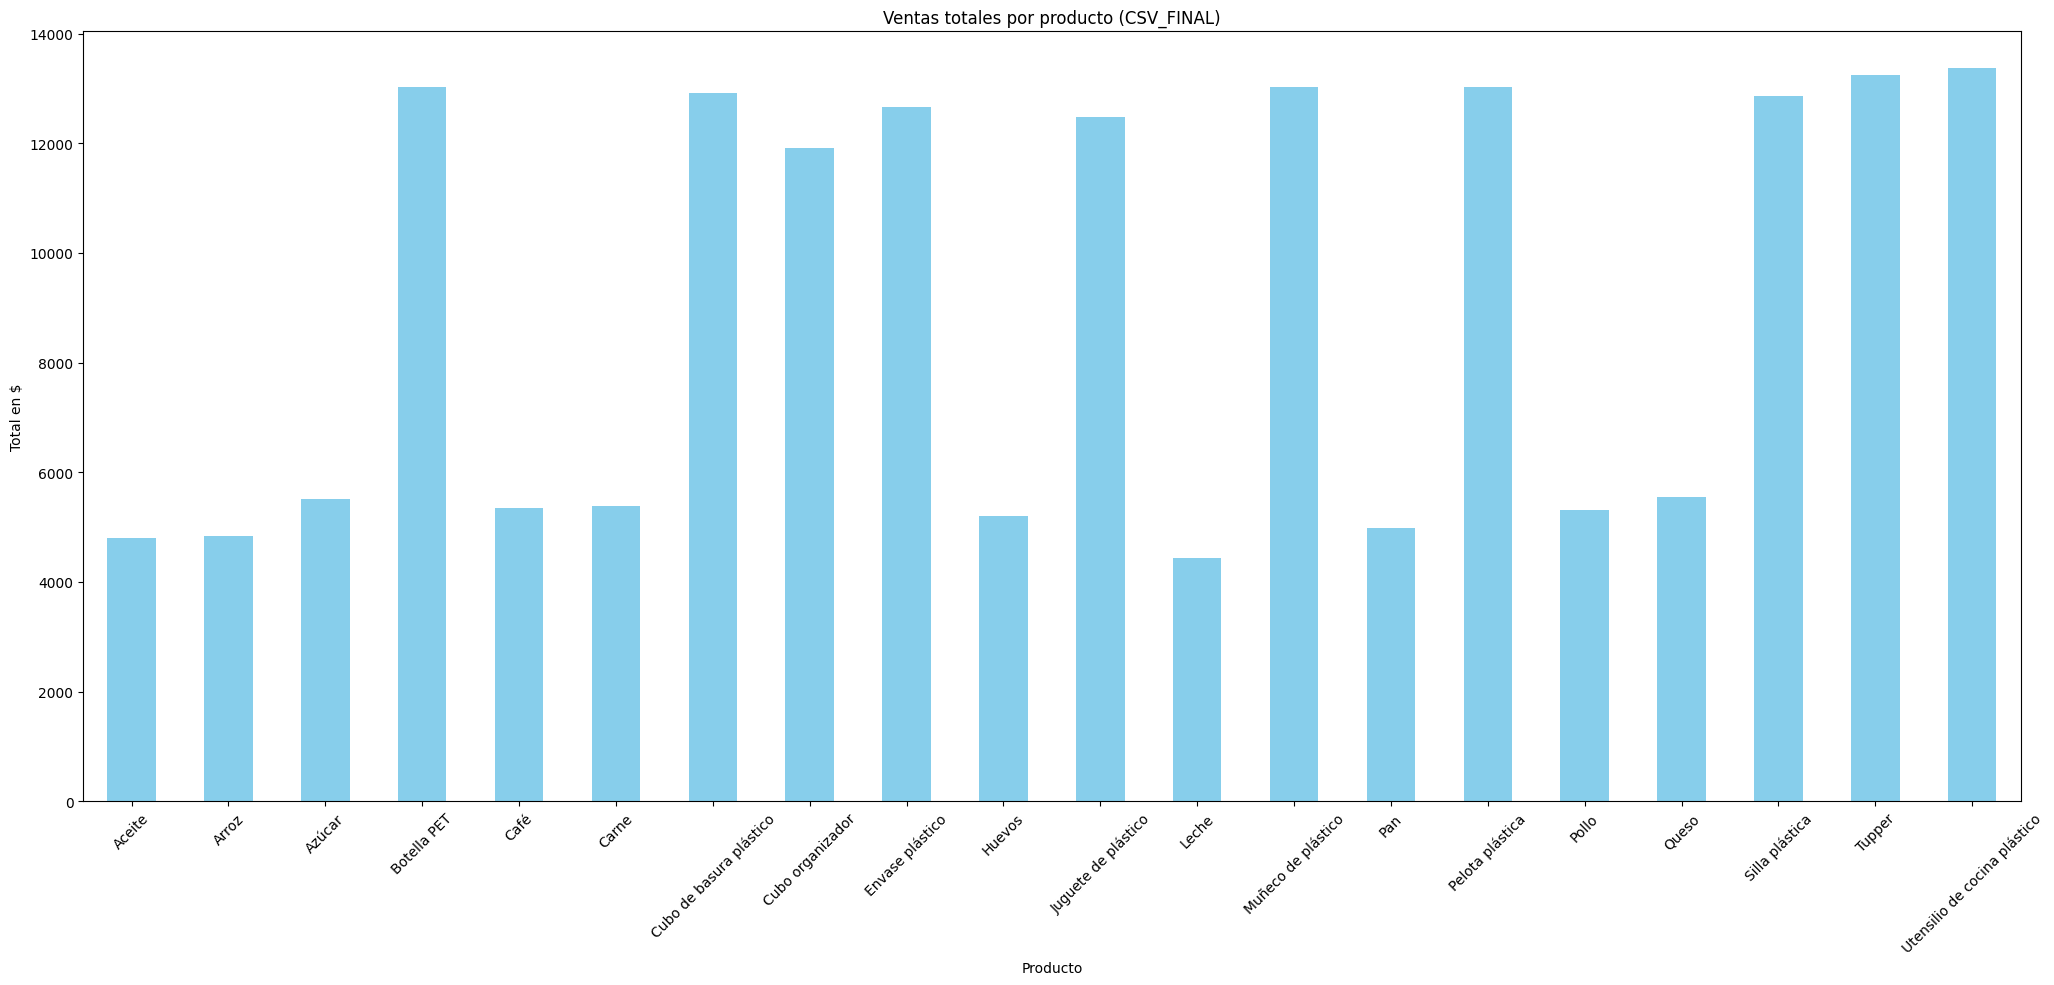

In [24]:
#Ventas totales por producto (CSV)
ventas_por_producto_final = df_final.groupby("Producto")["Precio"].sum()

# Identificar el productos de mayor ventas
producto_top = ventas_por_producto_final.idxmax()
precio_top = ventas_por_producto_final.max()

print("El producto con más ventas fue ", producto_top, "con la cantidad en $", precio_top)

plt.figure(figsize=(25,10))
ventas_por_producto_final.plot(kind="bar", color="skyblue")
plt.title("Ventas totales por producto (CSV_FINAL)")
plt.xlabel("Producto")
plt.ylabel("Total en $")
plt.xticks(rotation=45)
plt.show()

El mes con más ventas fue  2025-08 con 16028.69 unidades.


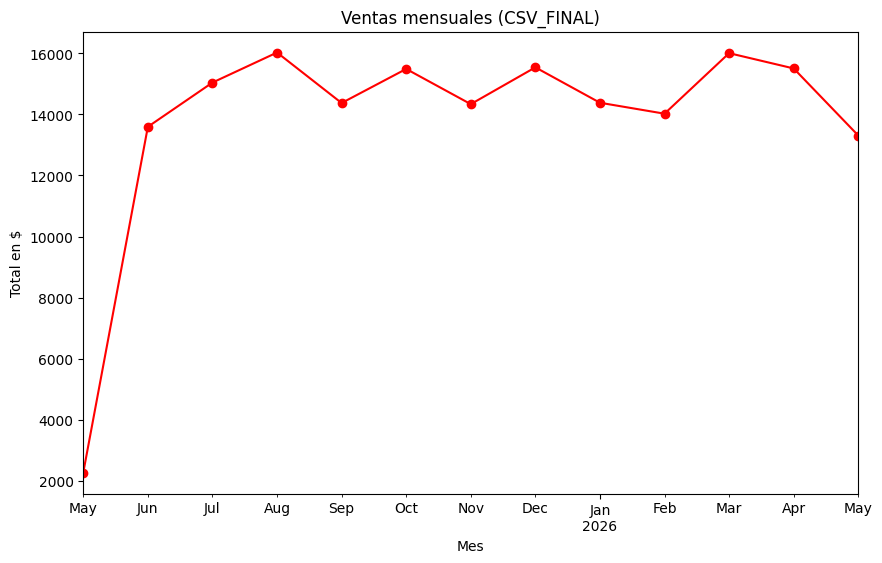

In [16]:
# Convertir a fecha
df_final["Fecha"] = pd.to_datetime(df_final["Fecha"])

# Agrupar por mes
ventas_mensuales_f = df_final.groupby(df_final["Fecha"].dt.to_period("M"))["Precio"].sum()

# Obtener el mes con más ventas
mes_top_f = ventas_mensuales_f.idxmax()
ventas_top_f = ventas_mensuales_f.max()

print("El mes con más ventas fue ", mes_top_f, "con", ventas_top_f, "unidades.")


plt.figure(figsize=(10,6))
ventas_mensuales_f.plot(kind="line", marker="o", color="red")
plt.title("Ventas mensuales (CSV_FINAL)")
plt.xlabel("Mes")
plt.ylabel("Total en $")
plt.show()

Fecha,Producto,Cantidad
2025-05,Juguete de plástico,142
2025-06,Muñeco de plástico,458
2025-07,Utensilio de cocina plástico,519
2025-08,Muñeco de plástico,655
2025-09,Silla plástica,502
2025-10,Pelota plástica,566
2025-11,Tupper,514
2025-12,Juguete de plástico,548
2026-01,Utensilio de cocina plástico,525
2026-02,Silla plástica,519


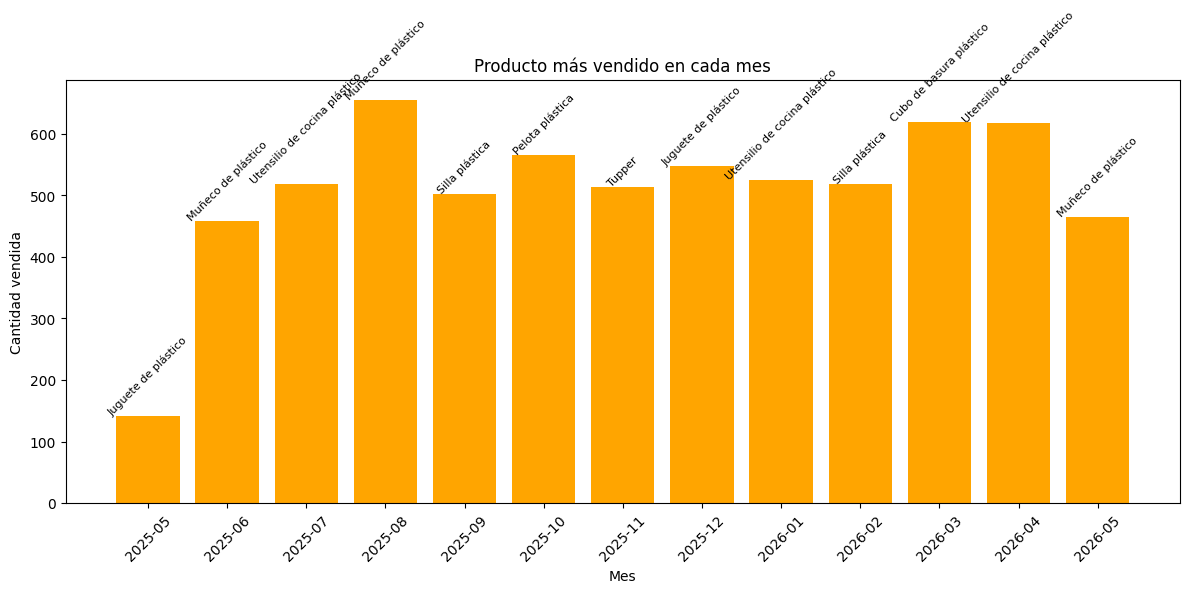

In [43]:
# Asegurarnos que la columna Fecha sea tipo datetime
df_final["Fecha"] = pd.to_datetime(df_final["Fecha"])

# Agrupar por mes y producto, sumando cantidades
ventas_mes_producto = df_final.groupby([df_final["Fecha"].dt.to_period("M"), "Producto"])["Cantidad"].sum().reset_index()


# Para cada mes, seleccionar el producto con mayor cantidad vendida
producto_top_mes = ventas_mes_producto.loc[ventas_mes_producto.groupby("Fecha")["Cantidad"].idxmax()]

#print(producto_top_mes)
producto_top_mes_ordenado = producto_top_mes.sort_values(by="Fecha")

display(
    producto_top_mes_ordenado.style
    .hide(axis="index")
    .set_caption("📊 Producto más vendido por mes")
    .set_properties(**{'text-align': 'center'})
    .background_gradient(subset=["Cantidad"], cmap="Greens")
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#2E86C1"), ("color", "white")]}
    ])
)
# Visualización: producto más vendido por mes
plt.figure(figsize=(12,6))
plt.bar(producto_top_mes["Fecha"].astype(str), producto_top_mes["Cantidad"], color="orange")

# Etiquetas con el nombre del producto encima de cada barra
for i, (mes, cantidad, producto) in enumerate(zip(producto_top_mes["Fecha"].astype(str), 
                                                  producto_top_mes["Cantidad"], 
                                                  producto_top_mes["Producto"])):
    plt.text(i, cantidad + 1, producto, ha="center", rotation=45, fontsize=8)

plt.title("Producto más vendido en cada mes")
plt.xlabel("Mes")
plt.ylabel("Cantidad vendida")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
